# Eikonal Distance and Fast-Marching Intuition

For speed $F(x)>0$, the arrival time $T$ solves
$$
\|\nabla T(x)\| F(x)=1.
$$
We design $F$ as a smooth mixture of two bumps so geodesics avoid the center, and visualize front propagation snapshots.


## Weighted grid and propagation snapshots


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

import heapq
OUT = Path("python/eikonal-fast-marching"); OUT.mkdir(parents=True, exist_ok=True)
n = 160
x = np.linspace(-1,1,n); y = np.linspace(-1,1,n)
X, Y = np.meshgrid(x, y)
slow = 1 + 3.4*np.exp(-((X-0.05)**2 + (Y-0.05)**2)/0.09) + 2.9*np.exp(-((X+0.18)**2 + (Y+0.16)**2)/0.06)
speed = 1.0 / slow
src = (n//2, 8)
dst = (n//2, n-10)

T = np.full((n,n), np.inf)
vis = np.zeros((n,n), dtype=bool)
par = np.full((n,n,2), -1, dtype=int)
T[src] = 0.0
pq = [(0.0, src[0], src[1])]
snaps = {}
marks = [2500, 6500, 12000, 18500]
cnt = 0
while pq:
    d, i, j = heapq.heappop(pq)
    if vis[i,j]:
        continue
    vis[i,j] = True
    cnt += 1
    if cnt in marks:
        snaps[cnt] = vis.copy()
    if (i,j) == dst:
        break
    for di,dj in [(-1,0),(1,0),(0,-1),(0,1)]:
        ii, jj = i+di, j+dj
        if 0 <= ii < n and 0 <= jj < n and not vis[ii,jj]:
            w = 0.5*(slow[i,j] + slow[ii,jj])
            nd = d + w
            if nd < T[ii,jj]:
                T[ii,jj] = nd
                par[ii,jj] = [i,j]
                heapq.heappush(pq, (nd, ii, jj))

path = []
i, j = dst
while (i, j) != src and i >= 0:
    path.append((i, j))
    i, j = par[i, j]
path.append(src)
path = np.array(path[::-1])


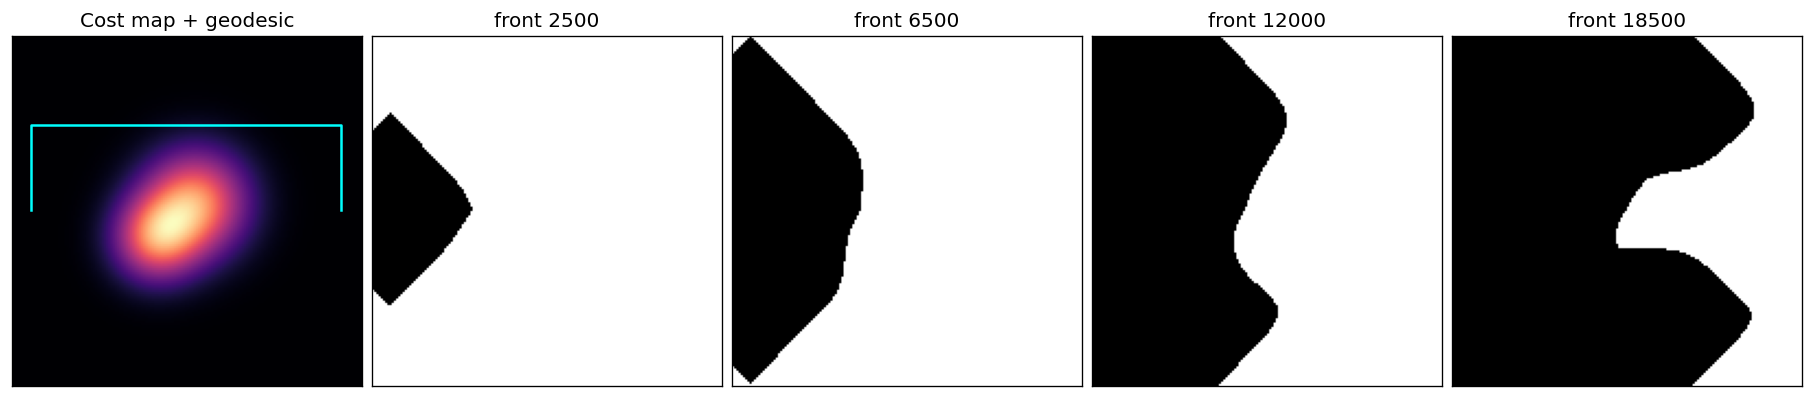

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(15.0, 3.3), constrained_layout=True)
axes[0].imshow(1/speed, origin="lower", cmap="magma")
axes[0].plot(path[:,1], path[:,0], color="cyan", lw=1.5)
axes[0].set_title("Cost map + geodesic")
axes[0].set_xticks([]); axes[0].set_yticks([])
for ax, m in zip(axes[1:], [2500, 6500, 12000, 18500]):
    ax.imshow(snaps[m], origin="lower", cmap="gray_r")
    ax.set_title(f"front {m}")
    ax.set_xticks([]); ax.set_yticks([])
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
